# Keyword Co-occurrence Network (KCN) Analysis

**Scoping Review:** *Strategies and protocols for selecting parameters and probability distributions in Agent-Based Models for social science research.*

**Objective:** To map the conceptual landscape and identify thematic clusters within the fragmented literature, a bibliometric network analysis was performed based on the keywords of the included studies.

**Methodology:** JBI / PRISMA-ScR | **Period:** 2015–2025 | **Databases:** SCOPUS, Web of Science, IEEE Xplore

---

## 0. Setup & Imports

In [46]:
import sys
import os
import warnings

# Add project root to path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from src.network_analysis import (
    DEFAULT_KEYWORD_MAP,
    parse_keywords,
    build_cooccurrence_edges,
    build_network,
    compute_node_metrics,
    compute_global_metrics,
    detect_communities,
    plot_network,
    plot_degree_distribution,
    plot_centrality_comparison,
    plot_community_heatmap,
    summarize_communities,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300})

# Output directory for figures
FIG_DIR = os.path.join(PROJECT_ROOT, "notebooks", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures dir:  {FIG_DIR}")

Project root: c:\Users\Thiago\Documents\GitHub\paper-scoping-review-protocol
Figures dir:  c:\Users\Thiago\Documents\GitHub\paper-scoping-review-protocol\notebooks\figures


## 1. Data Loading

The dataset was collected following the PRISMA-ScR protocol from SCOPUS, Web of Science,
and IEEE Xplore. After duplicate removal in Rayyan and screening by two blinded reviewers,
the final corpus was exported with structured metadata including author keywords (`Manual Tags`).

In [47]:
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "ReviewArticlesCleanFinal.xlsx")
df = pd.read_excel(DATA_PATH, engine="openpyxl")

print(f"Dataset shape: {df.shape[0]} articles x {df.shape[1]} columns")
df.head(3)

Dataset shape: 348 articles x 10 columns


,Key,Author,Title,Data Source (Parameterization),Model Objective (optional),Sensitivity Analysis,DOI,Abstract Note,Publication Year,Manual Tags
0,9D8JUUVQ,E. Alvarez; J. G. Brida; N. Garrido,Crowding Types and Price Dynamics in Tourism D...,Theoretical (literature),Exploratory; Decision Support / Policy Evaluation,NA; Exploratory / Scenario-based,10.1109/TCSS.2022.3230201,This article analyzes how the preferences of t...,2024,Costs; price dynamics; complex systems; Analyt...
1,GG8VFJQX,L. M. Pantoja-Rojas; M. A. Alzate-Monroy; V. H...,Cognitive Agent-Based Modeling to Optimize Com...,Theoretical (literature),Exploratory,Global (Variance-based); Global (Screening),10.1109/ACCESS.2025.3588816,This paper presents an agent-based simulation ...,2025,Simulation; Uncertainty; Agent-based modeling;...
2,9CLYR4IQ,"S-Alotibi, Y.S.",A socio-technical agent-based simulation model...,Theoretical (literature); Empirical (macro),Predictive; Decision Support / Policy Evaluation,Exploratory / Scenario-based; Regression / Sta...,10.1038/s41598-025-27523-7,Traditional technology adoption models in agri...,2025,Agent-based modeling; Agricultural innovation;...


## 2. Exploratory Data Analysis (EDA)

Before constructing the network, an exploratory analysis is essential to understand the
distribution of publications over time, identify the main venues, and characterize the
keyword vocabulary. This step also reveals data quality issues such as keyword variants
that must be harmonized before network construction.

### 2.1 General Overview

Basic descriptive statistics about the corpus: total number of articles, time span,
journal diversity, and keyword coverage. A high percentage of articles with keywords
is desirable for the reliability of the co-occurrence analysis.

In [48]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total articles:         {len(df)}")
df['Publication Year'] = df['Publication Year'].astype(str).str[:4].astype(int)
print(f"Year range:             {df['Publication Year'].min()} - {df['Publication Year'].max()}")
# print(f"Unique journals:        {df['Publication Title'].nunique()}")
print(f"Articles with keywords: {df['Manual Tags'].notna().sum()} ({df['Manual Tags'].notna().mean():.1%})")
print(f"Missing keywords:       {df['Manual Tags'].isna().sum()}")

DATASET OVERVIEW
Total articles:         348
Year range:             2015 - 2025
Articles with keywords: 346 (99.4%)
Missing keywords:       2


### 2.2 Publication Trend

The temporal distribution of publications reveals the growth trajectory of the field.
An increasing trend indicates growing academic interest in methodological rigor for
ABM parameterization in social sciences.

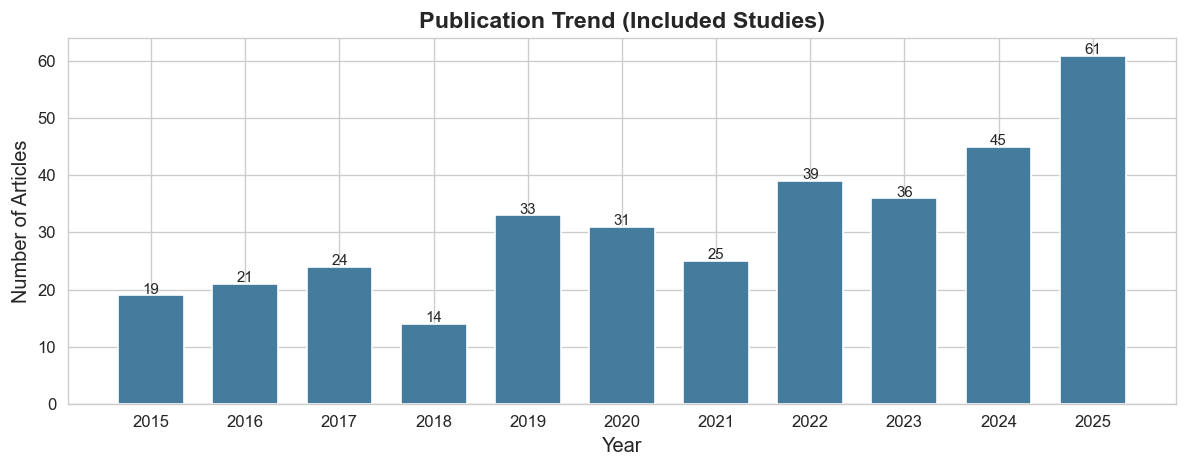

In [49]:
year_counts = df["Publication Year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4), facecolor="white")
ax.bar(year_counts.index, year_counts.values, color="#457B9D", edgecolor="white", width=0.7)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Articles", fontsize=12)
ax.set_title("Publication Trend (Included Studies)", fontsize=14, fontweight="bold")
ax.set_xticks(year_counts.index)
for i, v in enumerate(year_counts.values):
    ax.text(year_counts.index[i], v + 0.3, str(v), ha="center", fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "publication_trend.png"), dpi=300, bbox_inches="tight")
plt.show()

### 2.3 Top Journals

Identifying the most frequent publication venues helps characterize the disciplinary
landscape of the review. Journals from environmental science, economics, and computational
social science are expected given the scope of the search strategy.

In [50]:
df.columns

Index(['Key', 'Author', 'Title', 'Data Source (Parameterization)',
       'Model Objective (optional)', 'Sensitivity Analysis', 'DOI',
       'Abstract Note', 'Publication Year', 'Manual Tags'],
      dtype='str')

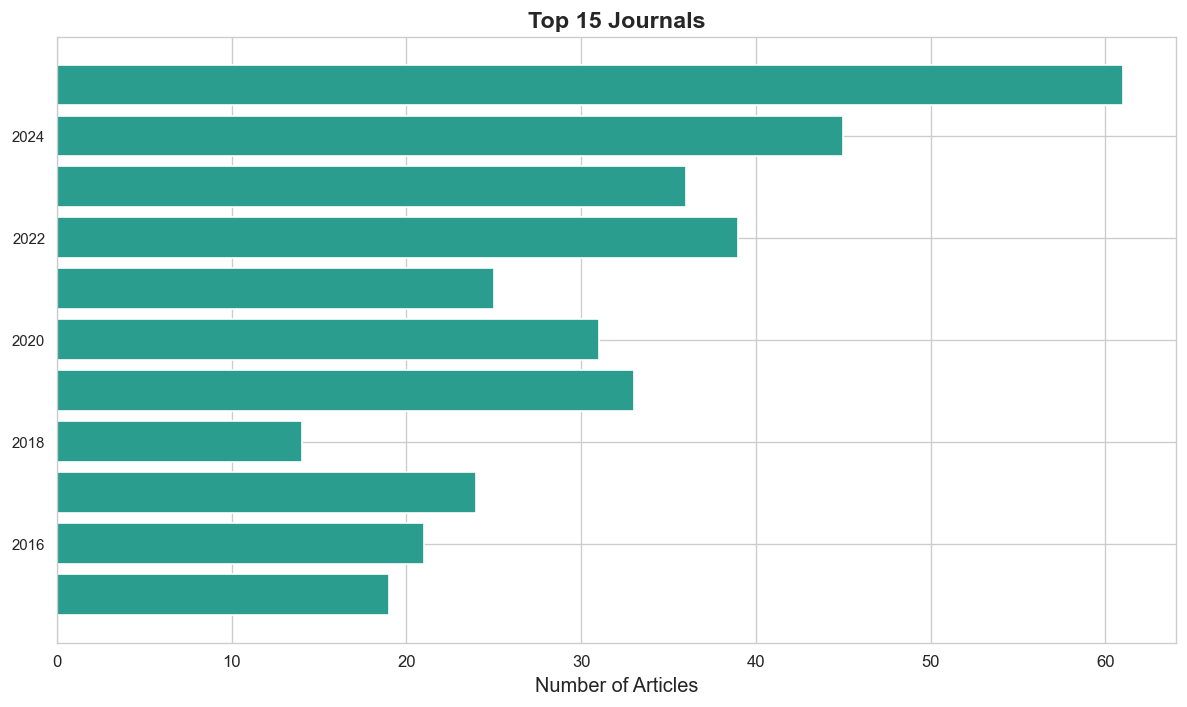

In [51]:
top_journals = df["Publication Year"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.barh(top_journals.index[::-1], top_journals.values[::-1], color="#2A9D8F", edgecolor="white")
ax.set_xlabel("Number of Articles", fontsize=12)
ax.set_title("Top 15 Journals", fontsize=14, fontweight="bold")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "top_journals.png"), dpi=300, bbox_inches="tight")
plt.show()

### 2.4 Keyword Harmonization Protocol

**Problem:** Author keywords frequently contain morphological, orthographic, and lexical
variants of the same concept. If left unharmonized, these inflate the node count and
dilute the co-occurrence signal, producing a sparser, noisier network that compromises
reproducibility and analytical validity.

**Protocol:** A four-step controlled vocabulary harmonization was applied:

1. **Lowercase normalization:** All keywords were converted to lowercase to eliminate
   case-based duplicates (e.g., "Agent-Based Model" → "agent-based model").

2. **Whitespace and punctuation trimming:** Leading/trailing whitespace and inconsistent
   delimiters were standardized.

3. **Synonym merging via controlled vocabulary (thesaurus):** A manually curated lookup
   table maps known variants to canonical forms. The mapping rules fall into five categories:
   - *Singular/plural unification* (e.g., "agent-based models" → "agent-based modeling")
   - *Spelling variant normalization* (e.g., British "modelling" → American "modeling")
   - *Hyphenation normalization* (e.g., "agent based model" → "agent-based modeling")
   - *Abbreviation expansion* (e.g., "ABM", "ABMs" → "agent-based modeling")
   - *Scope unification* (e.g., "land use" → "land-use change")

4. **Post-merge deduplication:** After harmonization, duplicate keywords within the same
   article (arising from two variants mapping to the same canonical form) were removed.

The complete thesaurus is provided in **Supplementary Table S1**. Representative examples
are shown below.

In [52]:
from src.network_analysis import DEFAULT_KEYWORD_MAP

# Display the thesaurus grouped by rule category
rules = {
    "Synonym / Inflection": [],
    "Spelling variant (UK/US)": [],
    "Hyphenation normalization": [],
    "Abbreviation expansion": [],
    "Scope unification": [],
}

# Classify each mapping
for variant, canonical in sorted(DEFAULT_KEYWORD_MAP.items()):
    v_lower = variant.lower()
    if v_lower in ("abm", "abms", "mas", "agent-based model (abm)"):
        rules["Abbreviation expansion"].append((variant, canonical))
    elif "modelling" in v_lower:
        rules["Spelling variant (UK/US)"].append((variant, canonical))
    elif " " in v_lower and "-" not in v_lower and any(
        c in v_lower for c in ("agent", "multi", "land")
    ):
        rules["Hyphenation normalization"].append((variant, canonical))
    elif v_lower.endswith("s") or v_lower.endswith("es"):
        rules["Synonym / Inflection"].append((variant, canonical))
    else:
        rules["Scope unification"].append((variant, canonical))

print("KEYWORD HARMONIZATION THESAURUS")
print(f"Total mappings: {len(DEFAULT_KEYWORD_MAP)}")
print("=" * 65)
for category, pairs in rules.items():
    if pairs:
        print(f"\n{category}:")
        for variant, canonical in pairs:
            print(f"  '{variant}'  →  '{canonical}'")

KEYWORD HARMONIZATION THESAURUS
Total mappings: 19

Synonym / Inflection:
  'agent-based models'  →  'agent-based modeling'
  'agent-based simulations'  →  'agent-based simulation'
  'sensitivity analyses'  →  'sensitivity analysis'

Spelling variant (UK/US):
  'agent based modelling'  →  'agent-based modeling'
  'agent-based modelling'  →  'agent-based modeling'

Hyphenation normalization:
  'agent based model'  →  'agent-based modeling'
  'agent based modeling'  →  'agent-based modeling'
  'agent based models'  →  'agent-based modeling'
  'land use'  →  'land-use change'
  'land use change'  →  'land-use change'
  'multi agent system'  →  'multi-agent systems'
  'multi agent systems'  →  'multi-agent systems'

Abbreviation expansion:
  'abm'  →  'agent-based modeling'
  'abms'  →  'agent-based modeling'
  'agent-based model (abm)'  →  'agent-based modeling'
  'mas'  →  'multi-agent systems'

Scope unification:
  'agent-based model'  →  'agent-based modeling'
  'decision making'  →  '

In [53]:
# --- RAW frequency (before harmonization) ---
raw_kws = df["Manual Tags"].dropna().str.split(";").explode().str.strip().str.lower()
raw_kws = raw_kws[raw_kws != ""]
raw_freq = raw_kws.value_counts()
n_raw = raw_freq.shape[0]

# --- Apply harmonization ---
df["kw_list"] = parse_keywords(df["Manual Tags"], sep=";")
df["n_keywords"] = df["kw_list"].apply(len)

all_keywords = [kw for kw_list in df["kw_list"] for kw in kw_list]
kw_freq = pd.Series(all_keywords).value_counts()
n_harmonized = kw_freq.shape[0]
n_merged = n_raw - n_harmonized

print("HARMONIZATION SUMMARY")
print("=" * 50)
print(f"  Unique keywords (raw):        {n_raw}")
print(f"  Unique keywords (harmonized): {n_harmonized}")
print(f"  Variants merged:              {n_merged}")
print(f"  Reduction:                    {n_merged/n_raw:.1%}")
print()

# Show the most impactful merges
print("MOST IMPACTFUL MERGES (by frequency gained):")
print("-" * 50)
for canonical in kw_freq.head(10).index:
    variants_merged = [v for v, c in DEFAULT_KEYWORD_MAP.items() if c == canonical]
    if variants_merged:
        raw_counts = {v: int(raw_freq.get(v, 0)) for v in variants_merged}
        raw_canonical = int(raw_freq.get(canonical, 0))
        total_after = int(kw_freq.get(canonical, 0))
        if sum(raw_counts.values()) > 0:
            print(f"\n  '{canonical}' (final count: {total_after})")
            if raw_canonical > 0:
                print(f"    original:  '{canonical}' = {raw_canonical}")
            for v, c in sorted(raw_counts.items(), key=lambda x: -x[1]):
                if c > 0:
                    print(f"    + merged:  '{v}' = {c}")

HARMONIZATION SUMMARY
  Unique keywords (raw):        1217
  Unique keywords (harmonized): 1203
  Variants merged:              14
  Reduction:                    1.2%

MOST IMPACTFUL MERGES (by frequency gained):
--------------------------------------------------

  'agent-based modeling' (final count: 225)
    original:  'agent-based modeling' = 71
    + merged:  'agent-based model' = 72
    + merged:  'agent-based modelling' = 38
    + merged:  'agent-based models' = 28
    + merged:  'agent-based model (abm)' = 6
    + merged:  'agent based modeling' = 3
    + merged:  'agent based modelling' = 3
    + merged:  'abm' = 2
    + merged:  'agent based model' = 1
    + merged:  'agent based models' = 1
    + merged:  'abms' = 1

  'decision-making' (final count: 10)
    original:  'decision-making' = 7
    + merged:  'decision making' = 3

  'land-use change' (final count: 7)
    original:  'land-use change' = 4
    + merged:  'land use' = 2
    + merged:  'land use change' = 1

  'mul

In [54]:
# Side-by-side: top 20 before vs after
comparison = pd.DataFrame({
    "Before Harmonization": raw_freq.head(20),
    "After Harmonization": kw_freq.head(20),
})
print("\nTOP 20 KEYWORDS: BEFORE vs AFTER HARMONIZATION")
print("=" * 60)
print("\nBEFORE:")
print(raw_freq.head(20).to_string())
print("\nAFTER:")
print(kw_freq.head(20).to_string())


TOP 20 KEYWORDS: BEFORE vs AFTER HARMONIZATION

BEFORE:
Manual Tags
agent-based model             72
agent-based modeling          71
agent-based modelling         38
agent-based models            28
uncategorized                 24
complex systems               14
simulation                    14
validation                     8
agent-based simulation         7
decision-making                7
sensitivity analysis           7
covid-19                       6
social influence               6
climate change                 6
calibration                    6
agent-based model (abm)        6
agent-based modeling (abm)     6
circular economy               5
opinion dynamics               5
model validation               5

AFTER:
agent-based modeling          225
uncategorized                  24
simulation                     14
complex systems                13
decision-making                10
validation                      8
agent-based simulation          7
land-use change          

In [55]:
# Export full thesaurus for Supplementary Material
thesaurus_rows = []
for variant, canonical in sorted(DEFAULT_KEYWORD_MAP.items()):
    # Determine rule category
    v = variant.lower()
    if v in ("abm", "abms", "mas", "agent-based model (abm)"):
        cat = "Abbreviation expansion"
    elif "modelling" in v:
        cat = "Spelling variant (UK/US)"
    elif " " in v and "-" not in v:
        cat = "Hyphenation normalization"
    elif v.endswith("s") and not v.endswith("ss"):
        cat = "Singular/Plural unification"
    else:
        cat = "Synonym merging"

    thesaurus_rows.append({
        "Variant": variant,
        "Canonical Form": canonical,
        "Rule Category": cat,
        "Raw Frequency": int(raw_freq.get(variant, 0)),
    })

thesaurus_df = pd.DataFrame(thesaurus_rows)
thesaurus_df = thesaurus_df.sort_values(["Rule Category", "Canonical Form", "Variant"])
thesaurus_path = os.path.join(FIG_DIR, "Table_S1_keyword_harmonization_thesaurus.csv")
thesaurus_df.to_csv(thesaurus_path, index=False)

print(f"Supplementary Table S1 exported to: {thesaurus_path}")
print(f"Total mappings: {len(thesaurus_df)}")
print(f"\nMappings per category:")
print(thesaurus_df["Rule Category"].value_counts().to_string())

Supplementary Table S1 exported to: c:\Users\Thiago\Documents\GitHub\paper-scoping-review-protocol\notebooks\figures\Table_S1_keyword_harmonization_thesaurus.csv
Total mappings: 19

Mappings per category:
Rule Category
Hyphenation normalization      9
Abbreviation expansion         4
Singular/Plural unification    2
Spelling variant (UK/US)       2
Synonym merging                2


In [56]:
# --- RAW frequency (before harmonization) ---
raw_kws = df["Manual Tags"].dropna().str.split(";").explode().str.strip().str.lower()
raw_freq = raw_kws.value_counts()

print("TOP 20 KEYWORDS — BEFORE HARMONIZATION")
print("=" * 50)
print(raw_freq.head(20).to_string())

print(f"\nUnique keywords (raw): {raw_freq.shape[0]}")

TOP 20 KEYWORDS — BEFORE HARMONIZATION
Manual Tags
agent-based model             72
agent-based modeling          71
agent-based modelling         38
agent-based models            28
uncategorized                 24
complex systems               14
simulation                    14
validation                     8
agent-based simulation         7
decision-making                7
sensitivity analysis           7
covid-19                       6
social influence               6
climate change                 6
calibration                    6
agent-based model (abm)        6
agent-based modeling (abm)     6
circular economy               5
opinion dynamics               5
model validation               5

Unique keywords (raw): 1217


In [57]:
# Show the harmonization map being applied
print("HARMONIZATION MAP (key variants):")
print("=" * 50)
for variant, canonical in sorted(DEFAULT_KEYWORD_MAP.items()):
    print(f"  '{variant}'  -->  '{canonical}')")

HARMONIZATION MAP (key variants):
  'abm'  -->  'agent-based modeling')
  'abms'  -->  'agent-based modeling')
  'agent based model'  -->  'agent-based modeling')
  'agent based modeling'  -->  'agent-based modeling')
  'agent based modelling'  -->  'agent-based modeling')
  'agent based models'  -->  'agent-based modeling')
  'agent-based model'  -->  'agent-based modeling')
  'agent-based model (abm)'  -->  'agent-based modeling')
  'agent-based modelling'  -->  'agent-based modeling')
  'agent-based models'  -->  'agent-based modeling')
  'agent-based simulations'  -->  'agent-based simulation')
  'decision making'  -->  'decision-making')
  'land use'  -->  'land-use change')
  'land use change'  -->  'land-use change')
  'mas'  -->  'multi-agent systems')
  'multi agent system'  -->  'multi-agent systems')
  'multi agent systems'  -->  'multi-agent systems')
  'multi-agent system'  -->  'multi-agent systems')
  'sensitivity analyses'  -->  'sensitivity analysis')


In [58]:
# --- Apply harmonization ---
df["kw_list"] = parse_keywords(df["Manual Tags"], sep=";")
df["n_keywords"] = df["kw_list"].apply(len)

all_keywords = [kw for kw_list in df["kw_list"] for kw in kw_list]
kw_freq = pd.Series(all_keywords).value_counts()

print("TOP 20 KEYWORDS — AFTER HARMONIZATION")
print("=" * 50)
print(kw_freq.head(20).to_string())

print(f"\nUnique keywords (harmonized): {kw_freq.shape[0]}")
print(f"Reduction: {raw_freq.shape[0]} -> {kw_freq.shape[0]} "
      f"(-{raw_freq.shape[0] - kw_freq.shape[0]} duplicates removed)")

TOP 20 KEYWORDS — AFTER HARMONIZATION
agent-based modeling          225
uncategorized                  24
simulation                     14
complex systems                13
decision-making                10
validation                      8
agent-based simulation          7
land-use change                 7
sensitivity analysis            7
multi-agent systems             7
covid-19                        6
social influence                6
climate change                  6
calibration                     6
agent-based modeling (abm)      6
circular economy                5
opinion dynamics                5
model validation                5
uncertainty                     4
sustainability                  4

Unique keywords (harmonized): 1203
Reduction: 1217 -> 1203 (-14 duplicates removed)


### 2.5 Keyword Frequency Distribution

The frequency distribution of keywords typically follows a power-law pattern in bibliometric
data: a small number of high-frequency terms dominate, while a long tail of rare terms appears
only once or twice. Understanding this distribution informs the choice of minimum co-occurrence
threshold for network filtering.

In [59]:
print(f"Total keyword occurrences: {len(all_keywords)}")
print(f"Unique keywords:           {kw_freq.shape[0]}")
print(f"Mean keywords per article: {df['n_keywords'].mean():.1f}")
print(f"Median keywords per article: {df['n_keywords'].median():.0f}")
print(f"\nKeywords appearing only once (hapax legomena): "
      f"{(kw_freq == 1).sum()} ({(kw_freq == 1).mean():.1%})")
print(f"Keywords appearing >= 2 times: {(kw_freq >= 2).sum()}")
print(f"Keywords appearing >= 3 times: {(kw_freq >= 3).sum()}")

Total keyword occurrences: 1709
Unique keywords:           1203
Mean keywords per article: 4.9
Median keywords per article: 5

Keywords appearing only once (hapax legomena): 1067 (88.7%)
Keywords appearing >= 2 times: 136
Keywords appearing >= 3 times: 51


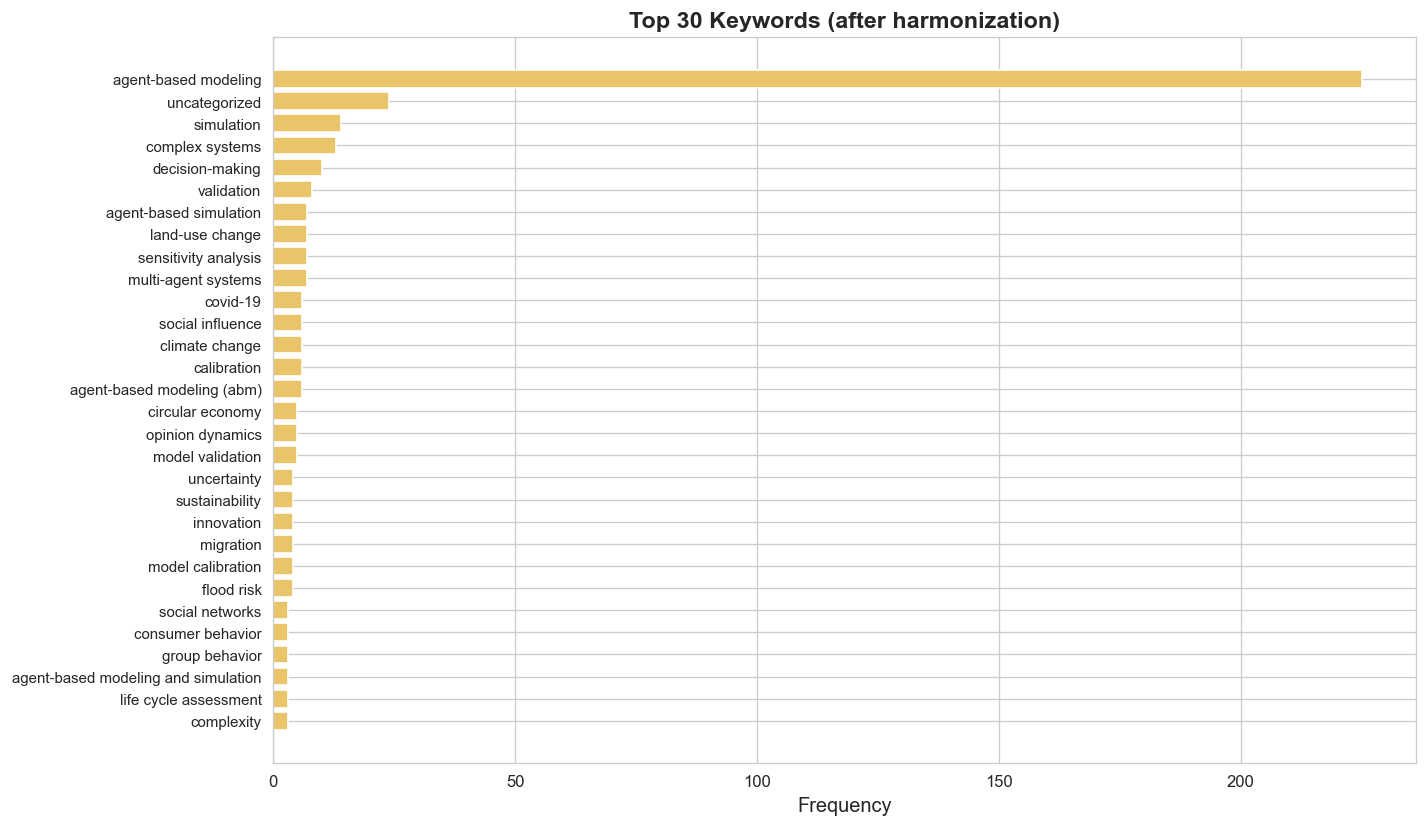

In [60]:
top_kw = kw_freq.head(30)

fig, ax = plt.subplots(figsize=(12, 7), facecolor="white")
ax.barh(top_kw.index[::-1], top_kw.values[::-1], color="#E9C46A", edgecolor="white")
ax.set_xlabel("Frequency", fontsize=12)
ax.set_title("Top 30 Keywords (after harmonization)", fontsize=14, fontweight="bold")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "top30_keywords.png"), dpi=300, bbox_inches="tight")
plt.show()

## 3. Network Construction

### Theoretical Foundation

A **Keyword Co-occurrence Network (KCN)** is a bibliometric instrument used to map the
intellectual structure of a research field (Callon et al., 1983; van Eck & Waltman, 2014).
The network is formally defined as an undirected weighted graph $G = (V, E, w)$ where:

- $V$ = set of unique keywords (nodes)
- $E$ = set of edges connecting keywords that co-occur in at least one article's keyword list
- $w: E \rightarrow \mathbb{N}$ = weight function, where $w(e_{ij})$ equals the number of
  articles in which keywords $i$ and $j$ appear together

The underlying assumption is that keywords that frequently co-occur address related research
topics. Clusters in this network reveal **thematic groups**, while central nodes represent
**conceptual pillars** of the field.

A **minimum co-occurrence threshold** is applied to filter noise from rare, uninformative
pairings. This threshold should be chosen carefully: too high removes meaningful but
emerging connections; too low introduces noise.

In [61]:
# --- 3.1 Build edge list ---
# Minimum co-occurrence threshold
MIN_COOCCURRENCE = 2

edge_df = build_cooccurrence_edges(df["kw_list"], min_edge_weight=MIN_COOCCURRENCE)

print(f"Edges with weight >= {MIN_COOCCURRENCE}: {len(edge_df)}")
print(f"\nTop 15 co-occurring keyword pairs:")
edge_df.sort_values("weight", ascending=False).head(15)

Edges with weight >= 2: 104

Top 15 co-occurring keyword pairs:


,source,target,weight
5,agent-based modeling,simulation,10
3,agent-based modeling,complex systems,9
4,agent-based modeling,decision-making,9
36,agent-based modeling,validation,7
59,agent-based modeling,land-use change,6
37,agent-based modeling,social influence,5
60,agent-based modeling,sensitivity analysis,5
35,agent-based modeling,innovation,4
47,agent-based modeling,covid-19,4
40,agent-based modeling,migration,4


In [62]:
# --- 3.2 Build NetworkX graph ---
G = build_network(edge_df)

print(f"Filtered network (threshold >= {MIN_COOCCURRENCE}):")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.4f}")

Filtered network (threshold >= 2):
  Nodes: 90
  Edges: 104
  Density: 0.0260


### 3.3 Full vs. Filtered Network Comparison

We also build the complete unfiltered network (min_weight=1) to assess the impact of
the threshold. A large reduction in edges with a small reduction in nodes indicates
effective noise removal without losing important concepts.

In [63]:
edge_df_full = build_cooccurrence_edges(df["kw_list"], min_edge_weight=1)
G_full = build_network(edge_df_full)

print(f"{'Metric':<25} {'Full (w>=1)':>12} {'Filtered (w>={MIN_COOCCURRENCE})':>15}")
print("-" * 55)
print(f"{'Nodes':<25} {G_full.number_of_nodes():>12} {G.number_of_nodes():>15}")
print(f"{'Edges':<25} {G_full.number_of_edges():>12} {G.number_of_edges():>15}")
print(f"{'Density':<25} {nx.density(G_full):>12.4f} {nx.density(G):>15.4f}")
print(f"\nEdge reduction: {1 - G.number_of_edges()/G_full.number_of_edges():.1%}")
print(f"Node reduction: {1 - G.number_of_nodes()/G_full.number_of_nodes():.1%}")

Metric                     Full (w>=1) Filtered (w>={MIN_COOCCURRENCE})
-------------------------------------------------------
Nodes                             1201              90
Edges                             3839             104
Density                         0.0053          0.0260

Edge reduction: 97.3%
Node reduction: 92.5%


## 4. Network Metrics

### Theoretical Foundation

Network metrics quantify structural properties at both the **global** (graph-level) and
**local** (node-level) scales. Together, they characterize the topology of the knowledge
structure.

**Global metrics** describe the overall connectivity and organization:
- **Density** ($\delta$): ratio of existing edges to all possible edges. Low density is
  typical of bibliometric networks, indicating specialized rather than uniform connections.
- **Average degree** ($\langle k \rangle$): mean number of neighbors per node.
- **Average clustering coefficient** ($\langle C \rangle$): measures the tendency of nodes
  to form tightly connected triangles, indicating local thematic cohesion.
- **Connected components**: number of isolated subgraphs. Ideally, one giant component
  dominates, indicating an integrated field.

In [64]:
# --- 4.1 Global metrics ---
global_stats = compute_global_metrics(G)

print("=" * 60)
print("GLOBAL NETWORK METRICS")
print("=" * 60)
for k, v in global_stats.items():
    if isinstance(v, float):
        print(f"  {k:35s} {v:.4f}")
    else:
        print(f"  {k:35s} {v}")

GLOBAL NETWORK METRICS
  nodes                               90
  edges                               104
  density                             0.0260
  avg_degree                          2.3111
  avg_weighted_degree                 6.1111
  avg_clustering                      0.0503
  connected_components                2
  diameter_largest_cc                 4
  avg_shortest_path_largest_cc        2.0805
  largest_cc_nodes                    88
  largest_cc_pct                      0.9778


### 4.2 Node-Level Centrality Metrics

**Centrality measures** identify the most important nodes in the network. Each metric
captures a different dimension of importance:

- **Degree centrality** ($C_D$): proportion of nodes a keyword is connected to.
  High degree = keyword co-occurs with many others = broad thematic relevance.

- **Weighted degree** (strength): sum of edge weights incident to the node.
  Captures not just how many connections, but how *strong* they are.

- **Betweenness centrality** ($C_B$): fraction of shortest paths between all node pairs
  that pass through a given node. High betweenness = keyword acts as a **bridge** between
  different thematic areas. These nodes are critical for knowledge integration.

- **Closeness centrality** ($C_C$): inverse of the average shortest path to all other nodes.
  High closeness = keyword is conceptually "close" to all other topics.

- **Eigenvector centrality** ($C_E$): measures influence by considering the centrality of
  a node's neighbors. A node connected to other highly connected nodes scores higher.

- **Clustering coefficient** ($C_i$): proportion of a node's neighbors that are also
  connected to each other. High clustering = keyword sits within a tightly-knit thematic group.

In [65]:
# --- 4.2 Node-level metrics ---
node_metrics = compute_node_metrics(G)

print("Top 20 keywords by Weighted Degree:")
node_metrics.head(20)

Top 20 keywords by Weighted Degree:


,degree,weighted_degree,degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality,clustering_coefficient
keyword,,,,,,,
agent-based modeling,82,231,0.921348,0.944076,0.924402,0.696366,0.001289
complex systems,8,23,0.089888,0.059414,0.503225,0.247913,0.098624
decision-making,3,13,0.033708,0.001532,0.488764,0.231897,0.320384
simulation,2,12,0.022472,0.000000,0.480480,0.235500,0.341995
complexity,4,9,0.044944,0.000000,0.491589,0.095731,0.239310
sensitivity analysis,3,9,0.033708,0.043412,0.488764,0.116797,0.066667
school segregation,4,8,0.044944,0.036985,0.491589,0.074034,0.226523
school choice,4,8,0.044944,0.036985,0.491589,0.074034,0.226523
flood risk,3,8,0.033708,0.000000,0.483210,0.100090,0.234656


### 4.3 Centrality Comparison

Comparing multiple centrality measures reveals whether importance is consistent across
dimensions or if certain keywords play specialized structural roles:
- A keyword ranking high in **weighted degree AND betweenness** is both popular and structurally
  critical (a central hub).
- A keyword with high **betweenness but low degree** is a rare but important bridge between
  otherwise disconnected communities.
- A keyword with high **eigenvector centrality** is embedded in the most influential neighborhood.

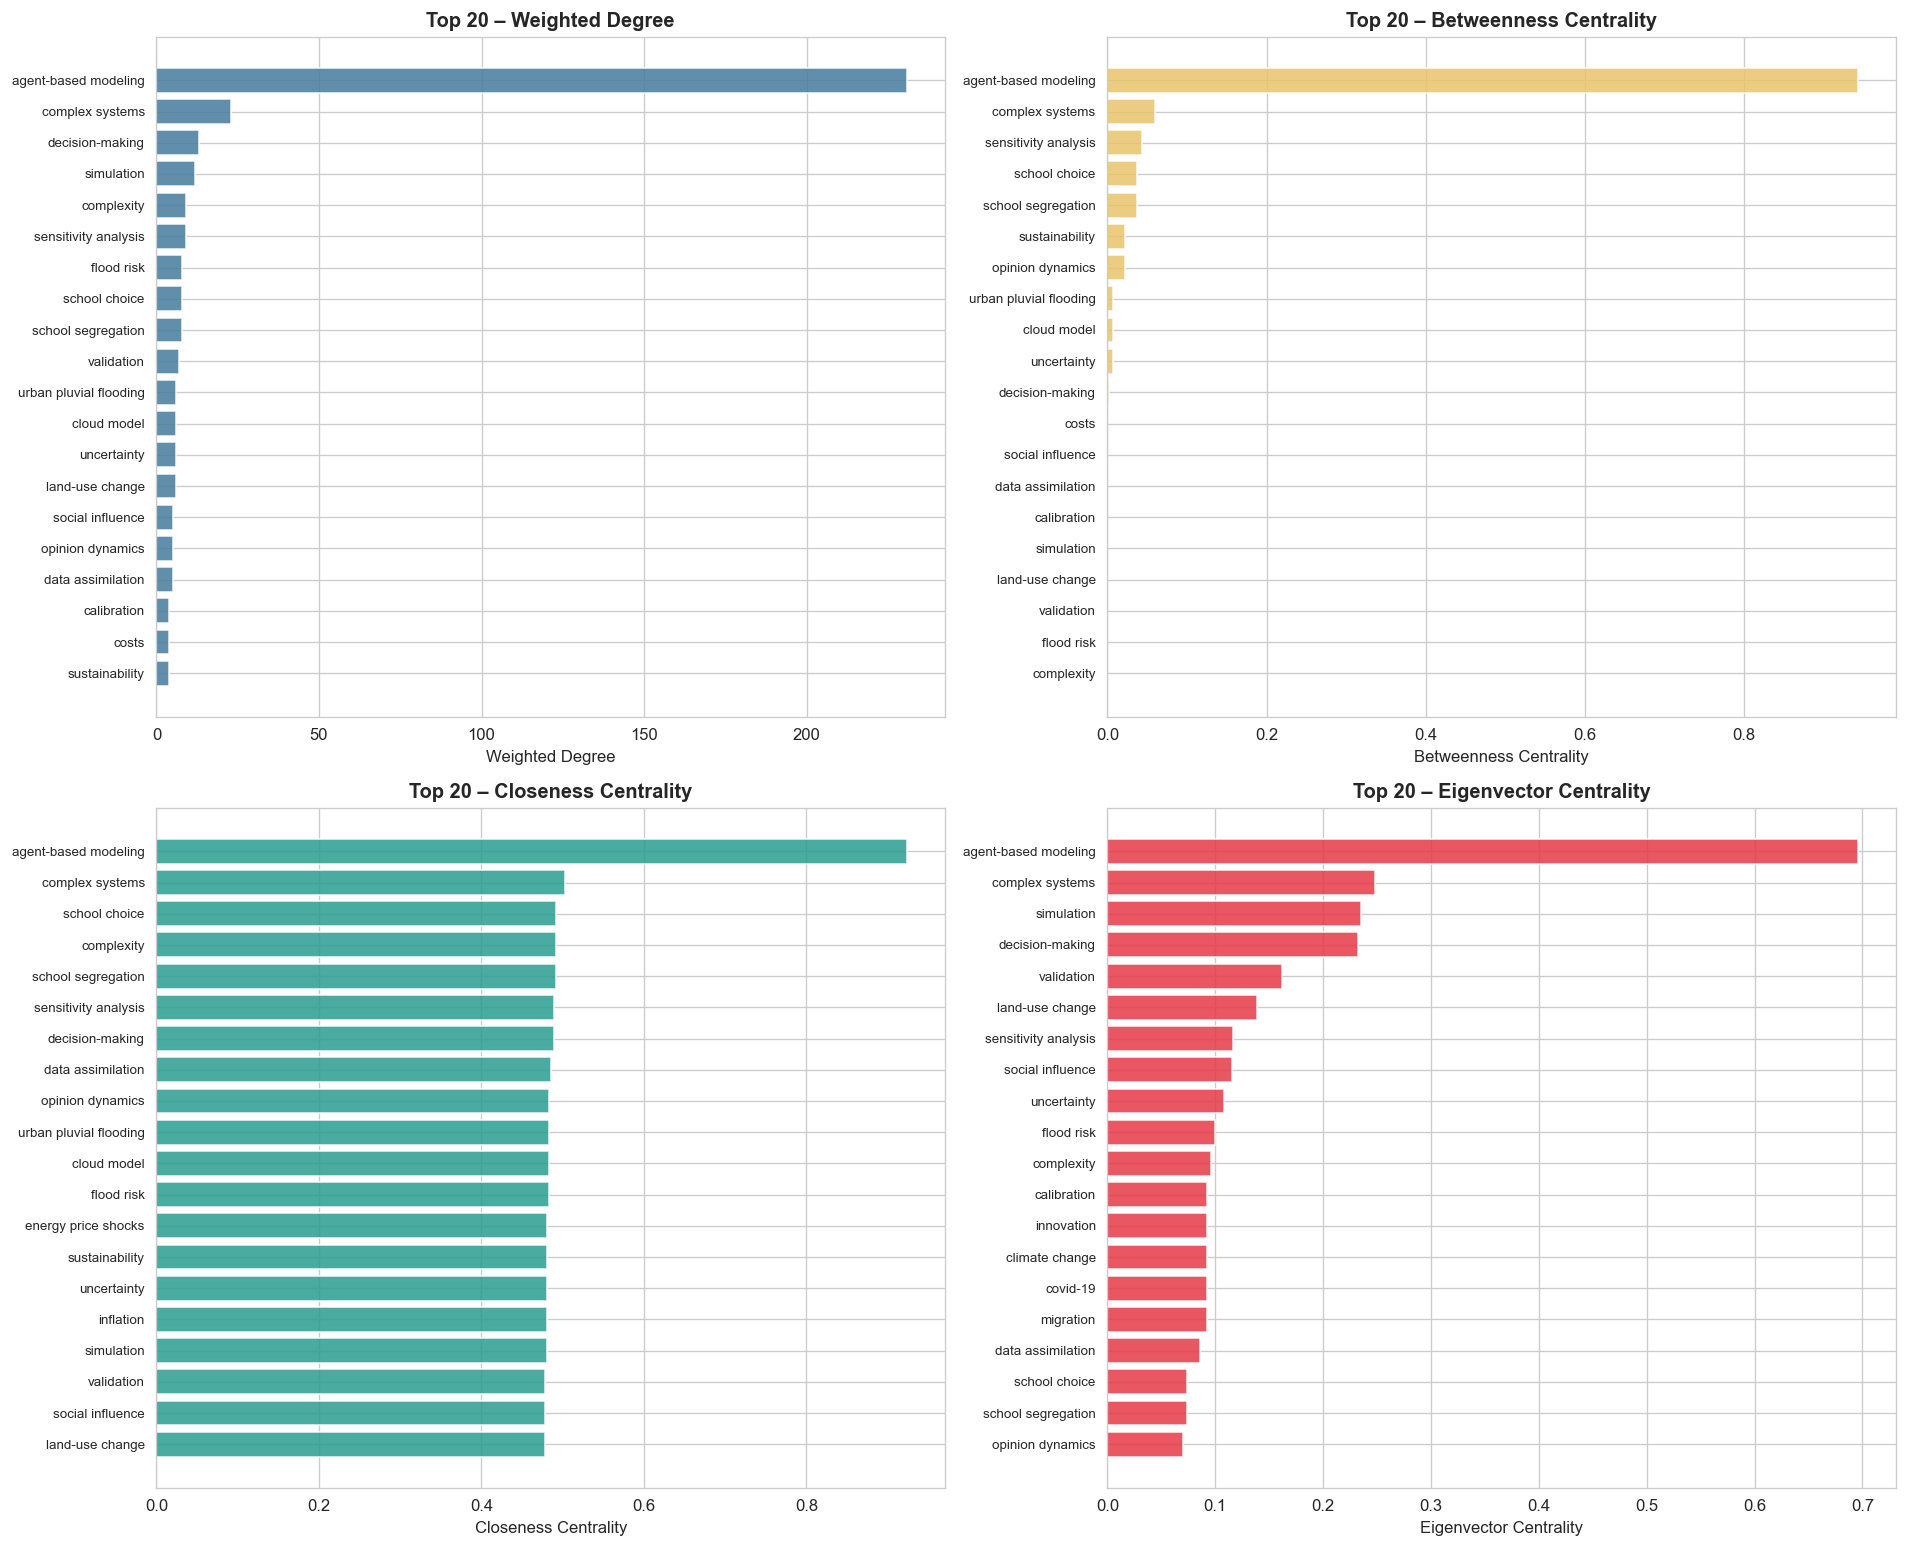

In [66]:
fig_cent = plot_centrality_comparison(
    node_metrics, top_n=20,
    save_path=os.path.join(FIG_DIR, "centrality_comparison.png")
)
plt.show()

### 4.4 Degree Distribution

The **degree distribution** $P(k)$ describes how connections are distributed across nodes.
In bibliometric networks, this distribution is typically right-skewed or follows a
power-law pattern $P(k) \sim k^{-\gamma}$, consistent with a **scale-free** topology
(Barabási & Albert, 1999).

A scale-free network implies:
- Most keywords have few connections (specialists)
- A few hub keywords concentrate many connections (generalists)
- The network is robust to random removal of nodes but vulnerable to targeted attacks on hubs

The **log-log plot** linearizes the power-law; a roughly linear pattern confirms the scale-free hypothesis.

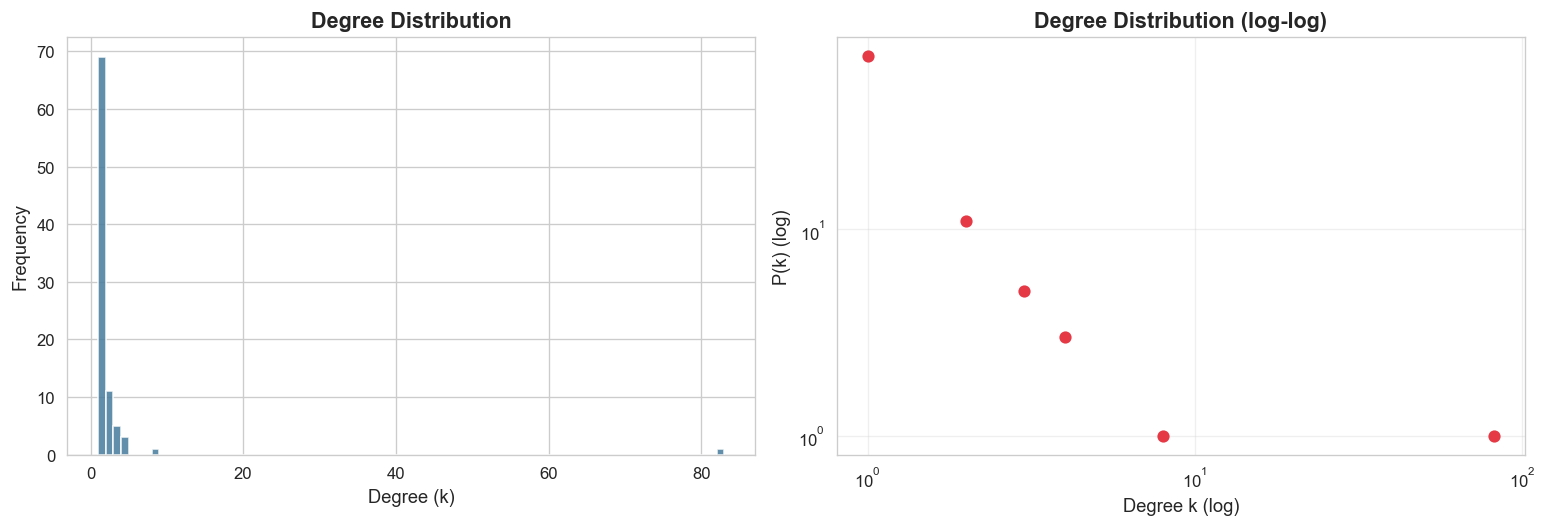

In [67]:
fig_deg = plot_degree_distribution(
    G,
    save_path=os.path.join(FIG_DIR, "degree_distribution.png")
)
plt.show()

## 5. Community Detection (Louvain Algorithm)

### Theoretical Foundation

**Community detection** identifies groups of densely interconnected nodes that are sparsely
connected to the rest of the network. In bibliometric networks, communities correspond to
**thematic clusters** — groups of keywords that tend to appear together in the same articles.

The **Louvain algorithm** (Blondel et al., 2008) is a greedy modularity optimization method
that iteratively assigns nodes to communities to maximize the **modularity** $Q$:

$$Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

where $A_{ij}$ is the adjacency matrix, $k_i$ is the degree of node $i$, $m$ is the total
number of edges, and $\delta(c_i, c_j) = 1$ if nodes $i$ and $j$ belong to the same community.

**Modularity interpretation:**
- $Q > 0.3$: indicates significant community structure
- $Q > 0.5$: strong community structure
- $Q > 0.7$: very strong community structure

The `resolution` parameter controls the granularity: higher values produce more, smaller
communities; lower values produce fewer, larger ones.

In [68]:
# --- 5.1 Detect communities ---
partition = detect_communities(G, resolution=1.0)
n_communities = len(set(partition.values()))

# Compute modularity
communities_sets = [{n for n, c in partition.items() if c == cid}
                    for cid in sorted(set(partition.values()))]
modularity = nx.community.modularity(G, communities_sets)

print(f"Number of communities detected: {n_communities}")
print(f"Modularity (Q): {modularity:.4f}")

if modularity > 0.7:
    print("Interpretation: Very strong community structure")
elif modularity > 0.5:
    print("Interpretation: Strong community structure")
elif modularity > 0.3:
    print("Interpretation: Significant community structure")
else:
    print("Interpretation: Weak community structure")

Number of communities detected: 7
Modularity (Q): 0.2204
Interpretation: Weak community structure


In [69]:
partition = detect_communities(G, resolution=1.0)
n_communities = len(set(partition.values()))

# Compute modularity
communities_sets = [{n for n, c in partition.items() if c == cid}
                    for cid in sorted(set(partition.values()))]
modularity = nx.community.modularity(G, communities_sets)

print(f"Number of communities detected: {n_communities}")
print(f"Modularity (Q): {modularity:.4f}")

Number of communities detected: 8
Modularity (Q): 0.2208


### 5.2 Modularity Significance Test (Configuration Model)

To assess whether the observed modularity reflects genuine community structure rather than
an artifact of the degree distribution, we compare $Q_{obs}$ against an ensemble of **1,000
random networks** generated using the **configuration model** (Newman, 2003). Each random
network preserves the original degree sequence but randomizes edge connections, thereby
serving as a null hypothesis of "no community structure beyond what is expected from the
degree distribution alone."

For each random network, the Louvain algorithm is applied with the same resolution parameter,
and the resulting modularity $Q_{null}$ is recorded. The statistical significance is evaluated
through:
- **Z-score:** $z = (Q_{obs} - \\mu_{null}) / \\sigma_{null}$
- **Empirical p-value:** proportion of null networks with $Q_{null} \\geq Q_{obs}$

In [70]:
from src.null_model import (
    modularity_significance_test,
    plot_modularity_significance,
    format_significance_report,
)

# Run significance test (1000 configuration-model random networks)
print("Running modularity significance test (1,000 random networks)...")
print("This may take a few minutes...\n")

sig_results = modularity_significance_test(
    G, partition,
    n_random=1000,
    resolution=1.0,
    weighted=True,
    seed=42,
)

# Print report
print(format_significance_report(sig_results))

Running modularity significance test (1,000 random networks)...
This may take a few minutes...

Modularity Significance Test (Configuration Model)
  Observed modularity (Q):     0.2208
  Null model mean (μ):         0.6169
  Null model std (σ):          0.0482
  Z-score:                     -8.22
  P-value:                     p = 1.000
  Random networks generated:   1000
  Significant (α=0.05):        False

  Interpretation: The observed modularity is -8.2 standard
  deviations above the null expectation, indicating that the
  community structure is not statistically significant
  despite a low absolute Q value.



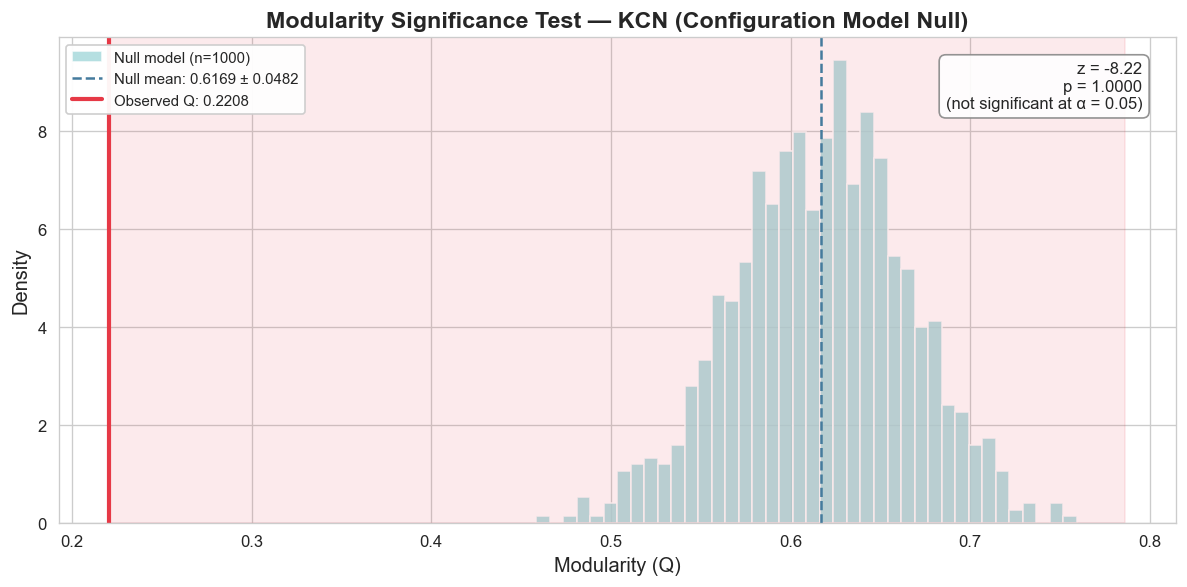

In [71]:
fig_sig = plot_modularity_significance(
    sig_results,
    title="Modularity Significance Test — KCN (Configuration Model Null)",
    figsize=(10, 5),
    save_path=os.path.join(FIG_DIR, "modularity_significance_test.png"),
)
plt.show()

### 5.3 Interpretation

The significance test compares the observed modularity against the null expectation
from degree-preserving random networks. Key considerations:

- A **z-score > 2** (approximately p < 0.05) indicates that the community structure is
  statistically significant — the observed clustering is unlikely to arise from the
  degree distribution alone.
- In **small, dense co-occurrence networks**, absolute modularity values tend to be low
  because many keywords co-occur broadly. The null model comparison contextualizes this:
  even a "low" Q can be highly significant if it substantially exceeds the null expectation.
- Conversely, if Q is not significantly above the null, the detected communities may
  reflect degree heterogeneity rather than genuine thematic structure.

In [72]:
comm_summary = summarize_communities(partition, node_metrics, top_n=7)
comm_summary

,community,size,top_keywords,avg_degree,avg_betweenness
0,0,7,complex systems; complexity; school segregatio...,3.714286,0.019055
1,1,3,flood risk; cloud model; urban pluvial flooding,3.000000,0.004824
2,2,69,agent-based modeling; simulation; validation; ...,2.202899,0.014001
3,3,2,decision-making; uncertainty,2.500000,0.004128
4,4,2,climate-change impacts; climate-change adaptation,1.000000,0.000000
5,5,2,opinion dynamics; public opinion,1.500000,0.010981
6,6,3,sensitivity analysis; review; individual-based...,2.333333,0.014471
7,7,2,energy price shocks; inflation,2.000000,0.000000


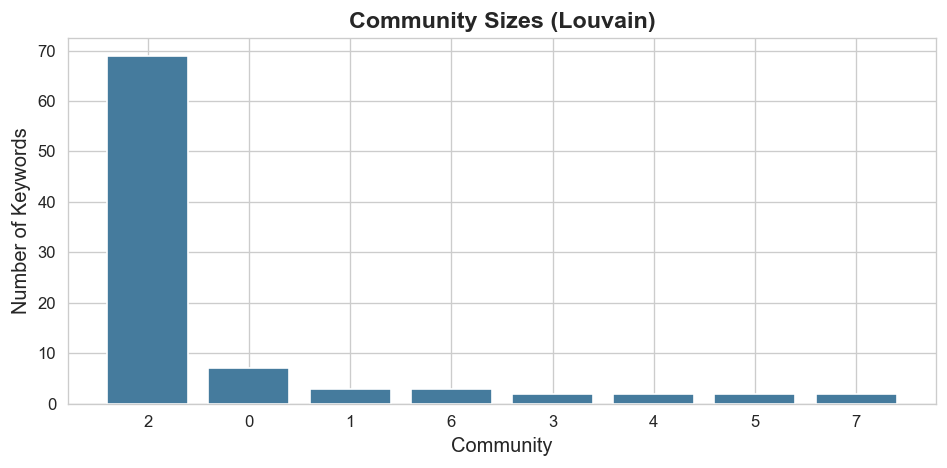

In [73]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor="white")
comm_summary_sorted = comm_summary.sort_values("size", ascending=False)
ax.bar(
    comm_summary_sorted["community"].astype(str),
    comm_summary_sorted["size"],
    color="#457B9D", edgecolor="white"
)
ax.set_xlabel("Community", fontsize=12)
ax.set_ylabel("Number of Keywords", fontsize=12)
ax.set_title("Community Sizes (Louvain)", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "community_sizes.png"), dpi=300, bbox_inches="tight")
plt.show()

### 5.2 Community Characterization

Each community is characterized by its size and the top keywords (ranked by weighted degree
within the community). The top keywords reveal the thematic identity of each cluster.
The researcher should assign interpretive labels based on domain knowledge.

In [74]:
comm_summary = summarize_communities(partition, node_metrics, top_n=7)
comm_summary

,community,size,top_keywords,avg_degree,avg_betweenness
0,0,7,complex systems; complexity; school segregatio...,3.714286,0.019055
1,1,3,flood risk; cloud model; urban pluvial flooding,3.000000,0.004824
2,2,69,agent-based modeling; simulation; validation; ...,2.202899,0.014001
3,3,2,decision-making; uncertainty,2.500000,0.004128
4,4,2,climate-change impacts; climate-change adaptation,1.000000,0.000000
5,5,2,opinion dynamics; public opinion,1.500000,0.010981
6,6,3,sensitivity analysis; review; individual-based...,2.333333,0.014471
7,7,2,energy price shocks; inflation,2.000000,0.000000


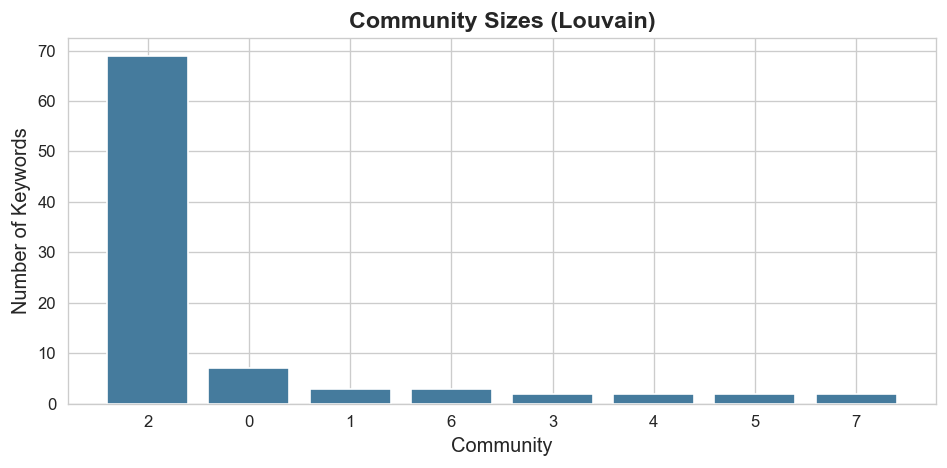

In [75]:
# --- Community sizes bar chart ---
fig, ax = plt.subplots(figsize=(8, 4), facecolor="white")
comm_summary_sorted = comm_summary.sort_values("size", ascending=False)
ax.bar(
    comm_summary_sorted["community"].astype(str),
    comm_summary_sorted["size"],
    color="#457B9D", edgecolor="white"
)
ax.set_xlabel("Community", fontsize=12)
ax.set_ylabel("Number of Keywords", fontsize=12)
ax.set_title("Community Sizes (Louvain)", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "community_sizes.png"), dpi=300, bbox_inches="tight")
plt.show()

### 5.3 Inter-Community Heatmap

The **inter-community heatmap** shows the total co-occurrence weight between every pair
of communities. Diagonal cells represent **intra-community** co-occurrence (internal cohesion),
while off-diagonal cells represent **inter-community** co-occurrence (thematic bridges).

A community with high diagonal values but low off-diagonal values is **thematically isolated**.
High off-diagonal values indicate **conceptual overlap** between communities — topics that
span multiple thematic areas.

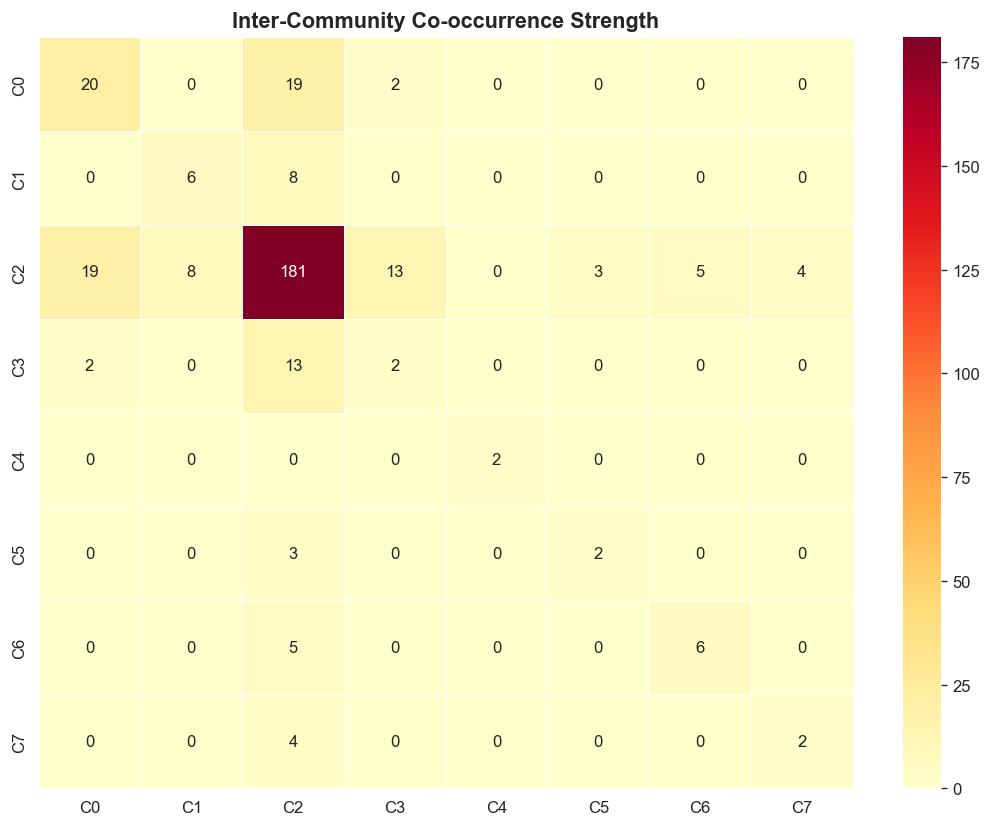

In [76]:
fig_hm = plot_community_heatmap(
    G, partition,
    save_path=os.path.join(FIG_DIR, "community_heatmap.png")
)
plt.show()

## 6. Network Visualization

### Design Choices

The network is visualized using a **force-directed layout** (Fruchterman-Reingold algorithm),
which positions nodes based on a physical simulation where edges act as springs and nodes
repel each other. This produces an intuitive spatial arrangement where:

- **Closely connected nodes cluster together** spatially
- **Node size** is proportional to weighted degree (importance)
- **Node color** encodes community membership (Louvain)
- **Edge thickness** is proportional to co-occurrence weight
- **Edge transparency** varies with weight (stronger = more opaque)

The layout parameter $k$ controls spacing: a lower $k$ produces a more **compact** graph
suitable for publication. Labels are shown only for the top-N keywords to avoid clutter.

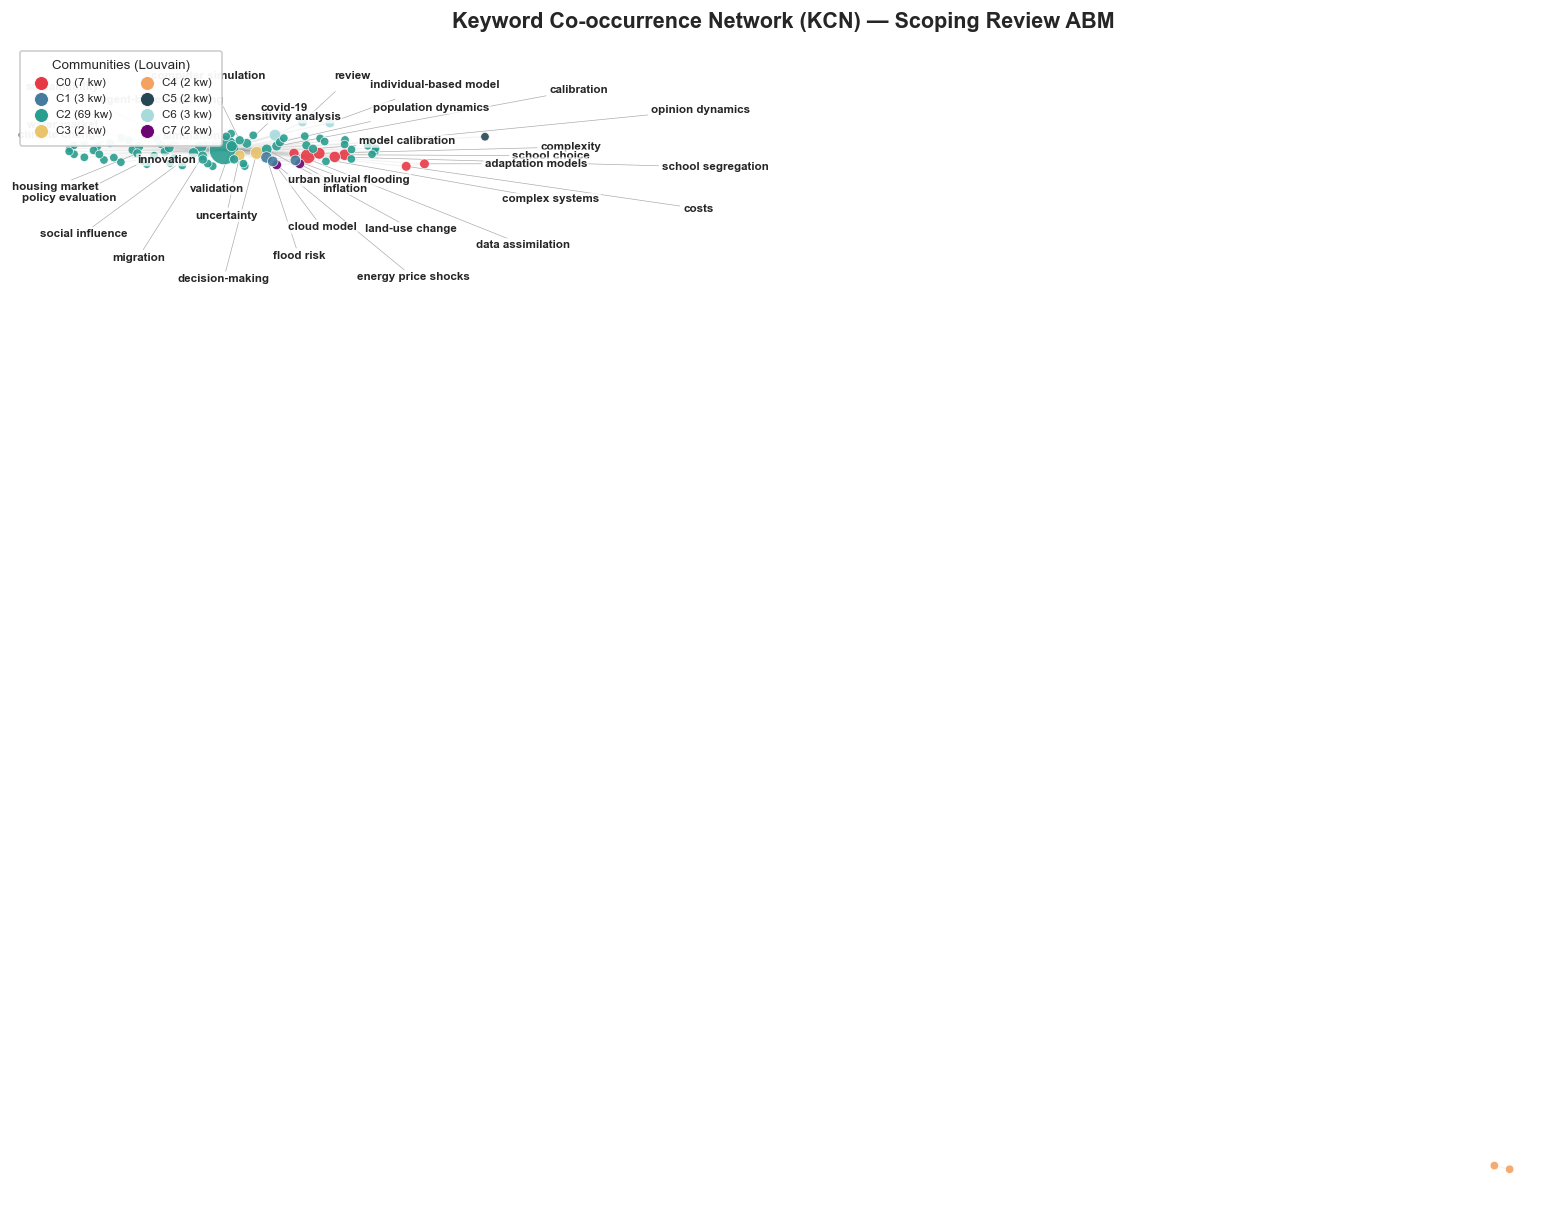

In [77]:
fig_net, ax_net = plot_network(
    G, partition, node_metrics,
    title="Keyword Co-occurrence Network (KCN) — Scoping Review ABM",
    figsize=(13, 10),
    node_scale=45,
    edge_alpha=0.20,
    font_size=7,
    top_n_labels=35,
    min_edge_weight_display=MIN_COOCCURRENCE,
    layout_k=None,         # auto-computed for compact layout
    layout_iterations=300, # more iterations = better convergence
    layout_seed=42,
    save_path=os.path.join(FIG_DIR, "kcn_network.png"),
)
plt.show()

## 7. Export Results

All analysis outputs are exported for reproducibility and further exploration:
- **CSV files** for metrics (node-level, global, community summaries, edge list)
- **GEXF file** for interactive exploration in Gephi (includes node attributes:
  community, centrality metrics)

In [78]:
# --- 7.1 Export node metrics with community labels ---
node_metrics["community"] = node_metrics.index.map(partition)
node_metrics.to_csv(os.path.join(FIG_DIR, "node_metrics.csv"))

# --- 7.2 Export edge list ---
edge_df.sort_values("weight", ascending=False).to_csv(
    os.path.join(FIG_DIR, "edge_list.csv"), index=False
)

# --- 7.3 Export community summary ---
comm_summary.to_csv(os.path.join(FIG_DIR, "community_summary.csv"), index=False)

# --- 7.4 Export global metrics ---
pd.DataFrame([global_stats]).T.rename(columns={0: "value"}).to_csv(
    os.path.join(FIG_DIR, "global_metrics.csv")
)

# --- 7.5 Export GEXF for Gephi ---
nx.set_node_attributes(G, partition, "community")
for n in G.nodes():
    if n in node_metrics.index:
        for col in ["weighted_degree", "betweenness_centrality",
                    "closeness_centrality", "eigenvector_centrality"]:
            val = node_metrics.loc[n, col]
            G.nodes[n][col] = float(val) if not pd.isna(val) else 0.0

nx.write_gexf(G, os.path.join(FIG_DIR, "kcn_network.gexf"))

print("All outputs exported to:", FIG_DIR)
for f in ["node_metrics.csv", "edge_list.csv", "community_summary.csv",
          "global_metrics.csv", "kcn_network.gexf"]:
    print(f"  - {f}")

All outputs exported to: c:\Users\Thiago\Documents\GitHub\paper-scoping-review-protocol\notebooks\figures
  - node_metrics.csv
  - edge_list.csv
  - community_summary.csv
  - global_metrics.csv
  - kcn_network.gexf


## 8. Summary Statistics for Manuscript

Consolidated table with all key metrics for direct inclusion in the results section
of the scoping review.

In [79]:
summary_table = {
    "Total articles analyzed": len(df),
    "Articles with keywords": int(df["Manual Tags"].notna().sum()),
    "Unique keywords (raw)": int(raw_freq.shape[0]),
    "Unique keywords (harmonized)": int(kw_freq.shape[0]),
    "Total keyword occurrences": len(all_keywords),
    "Min co-occurrence threshold": MIN_COOCCURRENCE,
    "Network nodes (full)": G_full.number_of_nodes(),
    "Network edges (full)": G_full.number_of_edges(),
    "Network nodes (filtered)": G.number_of_nodes(),
    "Network edges (filtered)": G.number_of_edges(),
    "Network density": f"{nx.density(G):.4f}",
    "Average degree": f"{global_stats['avg_degree']:.2f}",
    "Average weighted degree": f"{global_stats['avg_weighted_degree']:.2f}",
    "Average clustering coefficient": f"{global_stats['avg_clustering']:.4f}",
    "Connected components": global_stats['connected_components'],
    "Communities (Louvain)": n_communities,
    "Modularity (Q)": f"{modularity:.4f}",
}

summary_df = pd.DataFrame.from_dict(summary_table, orient="index", columns=["Value"])
summary_df.index.name = "Metric"
summary_df

,Value
Metric,
Total articles analyzed,348
Articles with keywords,346
Unique keywords (raw),1217
Unique keywords (harmonized),1203
Total keyword occurrences,1709
Min co-occurrence threshold,2
Network nodes (full),1201
Network edges (full),3839
Network nodes (filtered),90


---

**End of Notebook 01 — Keyword Co-occurrence Network (KCN)**

### Outputs generated:
| File | Description |
|------|-------------|
| `figures/kcn_network.png` | Main network visualization (publication-ready) |
| `figures/kcn_network.gexf` | Graph file for interactive exploration in Gephi |
| `figures/node_metrics.csv` | Per-keyword centrality metrics + community ID |
| `figures/edge_list.csv` | Weighted co-occurrence edge list |
| `figures/community_summary.csv` | Community characterization table |
| `figures/global_metrics.csv` | Graph-level summary statistics |
| `figures/centrality_comparison.png` | Top-20 centrality bar charts |
| `figures/degree_distribution.png` | Degree distribution (histogram + log-log) |
| `figures/community_heatmap.png` | Inter-community co-occurrence heatmap |
| `figures/community_sizes.png` | Community size distribution |